<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src=attachment:ad91936b-ffaa-4d78-8fca-1b445a35e3cd.jpg alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---
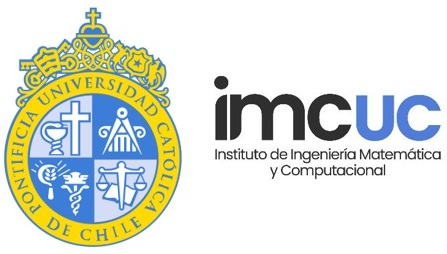

# <h1><center>Interrogación 2</center></h1>

## Instrucciones

* Esta parte de la Interrogación debe ser desarrollada completamente en lenguaje de programación Python en este Notebook de Jupyter.

* El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados, y siguiendo buenas prácticas de programación. <br>
* La entrega de la interrogación se realizará a través de Canvas en la actividad `I2 Desarrollo`.
* Esta Interrogación debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
* Está **estrictamente prohibido comunicarse con sus compañeros de curso, terceras personas o uso de IA** durante el desarrollo de esta interrogación.
* Puede consultar los apuntes del curso y soluciones disponibles en el repositorio del ramo.
* Habrá sólo dos instancias para hacer preguntas, una al inicio de la prueba y otra a los 30 minutos de avance.<br>


* Ud. dispone de 1 hora para desarrollar esta interrogación.
* Recuerde **guardar frecuentemente sus avances** para evitar pérdidas de trabajo o problemas de envío.<br>
---

## Parte 2: Trabajo de Desarrollo (60 min)

Esta parte de la Interrogación es un trabajo práctico con datos. En esta parte, cada pregunta debe ser respondida desarrollando un código por usted que le permita entregar una respuesta.

En esta sección, estaremos trabajando con dos bases de datos. En primer lugar, usaremos los registros de la Organización Mundial de la Salud (OMS) de las espectativas de vida en distintos países a través de los años (Disponible desde la [página web de la OMS](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/life-expectancy-at-birth-(years))) En segundo lugar, utilizaremos los datos de producto interno bruto (PIB) de distintos países (Disponible desde [Kaggle](https://www.kaggle.com/datasets/codebynadiia/gdp-per-country-20202025)).

Nuestro objetivo será explorar y analizar el comportamiento de estos datos, comprendiendo la relación entre estas dos variables, para finalmente entrenar modelos de regresión y evaluar su desempeño.

## 1. Lectura, limpieza y transformación (20 pts)

### 1.1 Lectura e inspección inicial (5 pts)
Usted dispone de los siguientes archivos:
* `pib2020-2025.csv`: contiene información del PIB en mil millones de USD de varios países entre los años 2020 y 2025.
* `WHO_life_expectancy.csv`: dataset de la OMS que contiene información sobre la espectativa de vida en varios países y años.

Para comenzar, cargue los dos archivos en dos dataframes separados llamados `pib_df`y `life_df`, respectivamente. Para cada uno, imprima la cantidad de filas que tiene, las columnas y sus tipos, y las primeras 5 filas.

In [180]:
#agregue las librerías que crea necesarios. Acá dejamos algunas estánadar que podrían ser de ayuda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [181]:
pib_df = pd.read_csv("data_2025/pib2020-2025.csv")
life_df = pd.read_csv("data_2025/WHO_life_expectancy.csv")

display(pib_df.head(5), life_df.head(5))

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7]
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9]
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6]
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8]
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1]


In [182]:
# cantidad y tipos de columnas
print("Cantidades y Tipos de PIB\n")
pib_df.info()
print("\nCantidades y Tipos de Expectativa de Vida\n")
life_df.info()

Cantidades y Tipos de PIB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB

Cantidades y Tipos de Expectativa de Vida

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        24420 non-null  object
 1   Indicator            24420 non-null  object
 2   ParentLocationCode   24420 non-null  object
 3   ParentLocation       24420 non-null  object
 4   Location typ

### 1.2 Limpieza de datos PIB (5 pts)

* Asegúrese de que su DataFrame `pib_df` no contenga valores nulos.
* Identifique si hay datos duplicados y elimínelos.
* Corrija los tipos de las columnas según corresponda, siempre justificando sus decisiones.

In [183]:
print(pib_df.isna().sum())
pib_df = pib_df.dropna() # eliminar nulos
print("\nCantidad de duplicados", pib_df.duplicated().sum()) # no hay duplicados

pib_df["Country"] = pib_df["Country"].astype(str)
pib_df["2020"] = pib_df["2020"].astype(float)
pib_df.dtypes

Country    0
2020       0
2021       2
2022       2
2023       2
2024       4
2025       7
dtype: int64

Cantidad de duplicados 0


Country     object
2020       float64
2021       float64
2022       float64
2023       float64
2024       float64
2025       float64
dtype: object

### 1.3 Filtrar datos de `life_df` (5 pts)

Esta vez, solo usaremos los valores de **espectativa de vida al nacer** para cada país según sexo.
Inspeccione su DataFrame y realice los siguientes pasos:

1. Elimine todas las filas que no correspondan a espectativas de vida al nacer.
2. Elimine todas las columnas que considere innecesarias. Justifique su elección.

In [184]:
life_df = life_df[life_df['Indicator'] == 'Life expectancy at birth (years)']
life_df = life_df.drop(columns=['IndicatorCode','Location type', 'Indicator', 'Dim1 type', 'Period type']) # son todos valores que no me aportan nada y se repiten todo el rato

life_df.head()

,ParentLocationCode,ParentLocation,SpatialDimValueCode,Location,Period,Dim1,Value
0,AFR,Africa,LSO,Lesotho,2021,Male,48.7 [47.8-49.7]
1,AFR,Africa,CAF,Central African Republic,2021,Male,49.6 [48.5-50.9]
2,AFR,Africa,LSO,Lesotho,2021,Both sexes,51.5 [50.5-52.6]
3,AFR,Africa,SWZ,Eswatini,2021,Male,51.6 [50.7-52.8]
4,EMR,Eastern Mediterranean,SOM,Somalia,2021,Male,51.7 [50.6-53.1]


### 1.4 Transformar valores de `life_df` (5 pts)

Podrá haber notado que la columna `Value` es un string de formato `n1 [n2-n3]`, donde `n1` es el valor promedio de la variable, mientras que `n2`y `n3` son los límites inferior y superior de la variable. Para nuestro análisis, solo nos interesa el valor promedio.

* Transforme la columna `Value` para que solo contenga el valor promedio (`n1`). Asegúrese de que el tipo de columna sea siempre el correcto.
* Imprima los estadísticos principales de esta columna (promedio, desviación estándar, mínimo y máximo, etc)


In [185]:
life_df["Value"] = life_df["Value"].apply(lambda x: x.split(" ")[0]) # me quedo con el valor promedio
life_df["Value"].info()
life_df["Value"] = life_df["Value"].astype(float)

<class 'pandas.core.series.Series'>
Index: 12210 entries, 0 to 23864
Series name: Value
Non-Null Count  Dtype 
--------------  ----- 
12210 non-null  object
dtypes: object(1)
memory usage: 190.8+ KB


In [186]:
# estadisticas generales, desviacion estandar, min, max, media, mediana, etc 
life_df["Value"].describe(include='all')

count    12210.000000
mean        70.174914
std          8.899653
min         36.600000
25%         64.200000
50%         71.900000
75%         77.100000
max         87.400000
Name: Value, dtype: float64

## 2. EDA univariado (27 pts)

Procederemos a explorar los datos contenidos dentro de `pib_df` y `life_df` por separado. Responda las siguientes preguntas, apoyándose de un gráfico cuando se le indique. No olvide colocar un título claro y etiquetas a los ejes de sus gráficos.

### 2.1 Valores del PIB (12 pts)

* ¿Entre qué magnitudes de valores se mueve el PIB de los países del mundo desde el año 2020 hasta 2025?
* ¿Cuáles son los 3 países con mayor PIB en 2025?
* ¿Cuáles son los 3 países con menor PIB en 2021?
* Seleccione un año de los disponibles y realice un histograma de los valores del PIB para ese año. ¿Cómo se distribuye esta variable? Comente.

In [187]:
rango = ["2020", "2021", "2022", "2023", "2024", "2025"]
for i in rango:
    print(f"pib minimo del año {i}: {pib_df[i].min()}, pib maximo del {i}: {pib_df[i].max()}")

pib minimo del año 2020: 52.0, pib maximo del 2020: 21354125.0
pib minimo del año 2021: 62.0, pib maximo del 2021: 23681175.0
pib minimo del año 2022: 61.0, pib maximo del 2022: 26006900.0
pib minimo del año 2023: 63.0, pib maximo del 2023: 27720725.0
pib minimo del año 2024: 65.0, pib maximo del 2024: 29184900.0
pib minimo del año 2025: 65.0, pib maximo del 2025: 30507217.0


Respuestas:

### 2.2 Esperanzas de vida (15 pts)

* ¿Cuántos países distintos hay representados dentro de `life_df`?
* ¿Cuál es el rango de años que contiene el dataset? ¿Cuáles de estos coinciden con los años que tenemos en `pib_df`?
* El dataset de la OMS le asigna un `ParentLocation` a cada país. Imprima todos los posibles valores y cuántas veces se repiten en su dataset `life_df`. ¿Cómo interpreta estas cantidades?
* Realice un boxplot que muestre la esperanza de vida según sexo y continente (o sector `ParentLocation`). Puede realizar uno o dos gráficos. Realice esta visualización solamente con los datos de 2021.

In [188]:
# paises distintos
life_df['Location'].nunique()

185

185 paises unicos en el dataset


In [189]:
# rango de años y total de años de los datasets

display(pib_df.columns, life_df["Period"].unique())




Index(['Country', '2020', '2021', '2022', '2023', '2024', '2025'], dtype='object')

array([2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011,
       2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000])

dada la baja cantidad de datos se puede ver a simplevista que coinciden los años 2020 y 2021


In [190]:
display(life_df["ParentLocation"].unique())
for x in range(6):
    print()


array(['Africa', 'Eastern Mediterranean', 'Western Pacific', 'Americas',
       'South-East Asia', 'Europe'], dtype=object)

Respuestas:

## 3. EDA multivariado (10 pts)

Ahora queremos entender la relación entre las variables del PIB y la esperanza de vida al nacer. Genere un único dataframe llamado `full_df` a partir de los dos datasets anteriores y responda las siguientes preguntas. De aquí en adelante, vamos a considerar **solamente** la esperanza de vida calculada para ambos sexos (Both sexes).

* ¿Cuál es la correlación entre el PIB de un país con la esperanza de vida al nacer? Calcule el valor para los años 2020 y 2021. ¿Qué nos indica este valor?

* Realice un scatterplot donde su eje X represente la esperanza de vida y su eje Y, el PIB. Comente lo que observa.

In [191]:
# respuestas

## 4. Transformación de escala (15 pts)

Ahora vamos a transformar la escala de nuestras variables para visualizar mejor la relación entre la espectativa de vida y PIB de los países.

* Genere las columnas `logPIB 2020` y `logPIB 2021`, donde el valor de cada columna corresponde al logaritmo en base 10 del PIB original. (Por ejemplo, si un valor de la columna `2020` es $x$, el valor correspondiente en la columna `logPIB 2020` debe ser $log_{10}(x)$

* Calcule nuevamente la correlación entre el PIB y la esperanza de vida al nacer para los dos años mencionados.

* Ahora, genere nuevamente un scatterplot entre la espectativa de vida promedio al nacer y su nueva representación del PIB para los años 2020 y 2021 por separado. ¿Puede ver alguna relación entre estas variables? Comente sus resultados.

In [192]:
# respuestas

## 5. Regresiones (28 pts)

Finalmente entrenaremos algunos modelos de regresión. Vamos a comparar el desempeño entre una regresión lineal y una **regresión logarítmica**, donde el valor a predecir ($y$), será calculado como:
$$ y = \beta_0 + \beta_1 \cdot log_{10}(X)$$

donde $X$ será nuestro PIB, $y$ corresponderá a la espectativa de vida al nacer y $\beta_0, \beta_1$ los coeficientes que calculará nuestro modelo.

En la práctica, vamos a partir realizando dos **regresión lineales**: la primera con la variable del PIB original y la segunda con nuestras nuevas columnas `logPIB` como nuestro $X$. 

En la siguiente sección, trabaje solamente con las esperanzas de vida de ambos sexos calculadas el año 2021.

In [193]:
# acá dejamos algunas librerías que pueden ser de utilidad, pero pueden agregar otras.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error as rmse
from sklearn.preprocessing import PolynomialFeatures

#### 5.1 Cree la matriz $X_1$ (PIB 2020 y 2021) y $X_2$ (log PIB 2020 y 2021), junto con el vector **y**. Luego separe cada uno en conjunto de entrenamiento y prueba con una división 70-30. (5 pts)
(Asigne explícitamente un valor a `random_state` para que su respuesta sea reproducible.)

In [194]:
# respuestas

#### 5.2 Entrene un modelo de regresión lineal para $X_1$. Imprima los coeficientes encontrados y calcule el RMSE y el $r^2$ para los conjuntos de entrenamiento y prueba. ¿Es una buena regresión? (10 pts)

In [195]:
# respuestas

Respuestas:

#### 5.3 Repita el proceso, esta vez para $X_2$. ¿Cómo se compara con la anterior? (6 pts)

In [196]:
# respuestas

Respuestas:

#### 5.4 Elija la variable con la que mejor desempeño obtuvo y entrene un modelo de regresión "polinomial" de grado 2, 3 y 4 con ella. Calcule nuevamente el RMSE y el $r^2$ para ambos conjuntos. ¿Mejoró su resultado? De todos los modelos, ¿cuál eligiría? (7 pts)

In [197]:
# respuestas

Respuestas: